# Decision Tree Regressor 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 04_decision_tree_regressor**

We implement `MyDecisionTreeRegressor` using recursive CART with MSE (variance reduction), supporting `max_depth`, `min_samples_split`, `min_samples_leaf` - then verify it against scikit-learn on REAL tips data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# load real data - tips
tips = sns.load_dataset('tips')
tips_enc = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)
X = tips_enc.drop(columns='tip').values
y = tips_enc['tip'].values
feature_names = tips_enc.drop(columns='tip').columns.tolist()

print('Data shape:', X.shape, 'Target range:', y.min(), '-', y.max())

Data shape: (244, 8) Target range: 1.0 - 10.0


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | recursively build tree maximizing variance reduction |
| `predict(X)` | traverse tree for each sample |
| `score(X, y)` | return R² |

Key parameters: `max_depth`, `min_samples_split`, `min_samples_leaf`, `random_state`.

Split quality = variance reduction: $\Delta = SSE_{parent} - (\tfrac{n_L}{n}SSE_L + \tfrac{n_R}{n}SSE_R)$

In [2]:
class MyDecisionTreeRegressor:
    """
    Decision Tree Regressor (CART) from scratch.

    Parameters
    ----------
    max_depth : int, default=None
        Maximum depth of the tree. None = expand until leaves are pure.
    min_samples_split : int, default=2
        Minimum samples required to split an internal node.
    min_samples_leaf : int, default=1
        Minimum samples required to be at a leaf node.
    random_state : int, default=None
        Seed for tie-breaking.

    Attributes after fit
    --------------------
    tree_ : dict - nested tree structure
    n_features_in_ : int - number of features
    """

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, random_state=None):
        # Configure the tree: growth limits, leaf limits, seed.
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    # split node
    def _sse(self, y):
        """Sum of squared errors:  SSE = sum_i (y_i - mean(y))^2 = n*Var(y)."""
        if len(y) == 0:
            return 0.0
        return float(np.sum((y - y.mean()) ** 2))

    def _best_split(self, X, y):
        """Find the feature + threshold maximising variance reduction.

        Gain(f, t) = SSE(parent) - (n_L*SSE_L + n_R*SSE_R) / n
        Threshold candidates are midpoints of consecutive unique values: t=(v_i+v_{i+1})/2
        """
        n_samples, n_features = X.shape
        if n_samples < self.min_samples_split:
            return None, None

        parent_sse = self._sse(y)
        best_gain = -1
        best_feature = None
        best_threshold = None

        rng = np.random.RandomState(self.random_state)
        feature_order = rng.permutation(n_features)         # random tie-breaking

        for feat_idx in feature_order:
            values = X[:, feat_idx]
            unique_vals = np.unique(values)
            if len(unique_vals) <= 1:
                continue
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2   # midpoints

            for threshold in thresholds:
                left_mask = values <= threshold
                right_mask = ~left_mask

                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                n_left = left_mask.sum()
                n_right = right_mask.sum()
                sse_left = self._sse(y[left_mask])
                sse_right = self._sse(y[right_mask])

                # variance reduction = drop in (scaled) total squared error
                gain = parent_sse - (n_left * sse_left + n_right * sse_right) / n_samples

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    # tree build
    def _build_tree(self, X, y, depth=0):
        """Recursively build the regression tree; returns nested dict nodes."""
        n_samples = len(y)

        # Stopping criteria -> leaf predicts the mean target of its samples
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           n_samples <= self.min_samples_leaf:
            return {
                'leaf': True,
                'mean': float(y.mean()),
                'n_samples': n_samples
            }

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return {
                'leaf': True,
                'mean': float(y.mean()),
                'n_samples': n_samples
            }

        # Split node: recurse on left and right partitions
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1),
            'n_samples': n_samples
        }

    # fit
    def fit(self, X, y):
        """Grow the regression tree on (X, y)."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        self.n_features_in_ = X.shape[1]
        self.tree_ = self._build_tree(X, y)
        return self

    # prediction
    def _predict_one(self, x, node):
        """Traverse the tree for one sample; return the leaf's mean target."""
        if node['leaf']:
            return node['mean']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        """Return the mean target (leaf value) predicted for every row in X."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    # score
    def score(self, X, y):
        """Return coefficient of determination R^2 on (X, y)."""
        return r2_score(y, self.predict(X))

    def __repr__(self):
        return (f"MyDecisionTreeRegressor(max_depth={self.max_depth}, "
                f"min_samples_split={self.min_samples_split}, "
                f"min_samples_leaf={self.min_samples_leaf})")

print('MyDecisionTreeRegressor class defined')


MyDecisionTreeRegressor class defined


### 2. Real data prep - tips

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

# Our implementation - unconstrained
mine = MyDecisionTreeRegressor(random_state=42).fit(X_tr, y_tr)
pred_mine = mine.predict(X_te)
r2_mine = r2_score(y_te, pred_mine)
mse_mine = mean_squared_error(y_te, pred_mine)

# sklearn - unconstrained
sk = DecisionTreeRegressor(random_state=42).fit(X_tr, y_tr)
pred_sk = sk.predict(X_te)
r2_sk = r2_score(y_te, pred_sk)
mse_sk = mean_squared_error(y_te, pred_sk)

print(f'MyDecisionTreeRegressor (unconstrained) R²:  {r2_mine:.4f}, MSE: {mse_mine:.4f}')
print(f'sklearn DecisionTreeRegressor (unconstrained) R²: {r2_sk:.4f}, MSE: {mse_sk:.4f}')
print(f'Train R² (ours): {r2_score(y_tr, mine.predict(X_tr)):.4f}')

MyDecisionTreeRegressor (unconstrained) R²:  -0.3278, MSE: 1.7665
sklearn DecisionTreeRegressor (unconstrained) R²: -0.1856, MSE: 1.5774
Train R² (ours): 1.0000


### 3. Pruning comparison - max_depth sweep

In [4]:
depths = range(1, 11)
results = []

for d in depths:
    m = MyDecisionTreeRegressor(max_depth=d, random_state=42).fit(X_tr, y_tr)
    s = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_tr, y_tr)
    results.append({
        'max_depth': d,
        'mine_train': r2_score(y_tr, m.predict(X_tr)),
        'mine_test': r2_score(y_te, m.predict(X_te)),
        'sklearn_train': r2_score(y_tr, s.predict(X_tr)),
        'sklearn_test': r2_score(y_te, s.predict(X_te))
    })

df = pd.DataFrame(results)
df.set_index('max_depth').round(4)

,mine_train,mine_test,sklearn_train,sklearn_test
max_depth,,,,
1,0.3165,0.2550,0.3165,0.2550
2,0.4178,0.3511,0.5472,0.1462
3,0.5181,0.2744,0.6072,0.3341
4,0.6953,-0.0746,0.6576,0.1432
5,0.7628,0.0208,0.7469,0.0887
6,0.9070,-0.1319,0.8371,0.0416
7,0.9718,-0.3708,0.8908,-0.1824
8,0.9970,-0.3364,0.9410,-0.2002
9,0.9994,-0.3251,0.9674,-0.1729


### 4. Visualize a small tree (depth=3)

Visualize our tree and compare with sklearn (should be near-identical structure).

=== Our tree (max_depth=3) ===
Node: X[0] <= 20.470, n=183
  Node: X[0] <= 15.790, n=111
    Node: X[0] <= 12.630, n=64
      Leaf: mean=1.8594, n=32
      Leaf: mean=2.2181, n=32
    Node: X[0] <= 17.030, n=47
      Leaf: mean=2.8011, n=18
      Leaf: mean=3.0524, n=29
  Node: X[0] <= 30.270, n=72
    Node: X[0] <= 24.650, n=47
      Leaf: mean=3.6848, n=25
      Leaf: mean=3.8155, n=22
    Node: X[3] <= 0.500, n=25
      Leaf: mean=3.6729, n=14
      Leaf: mean=6.0591, n=11


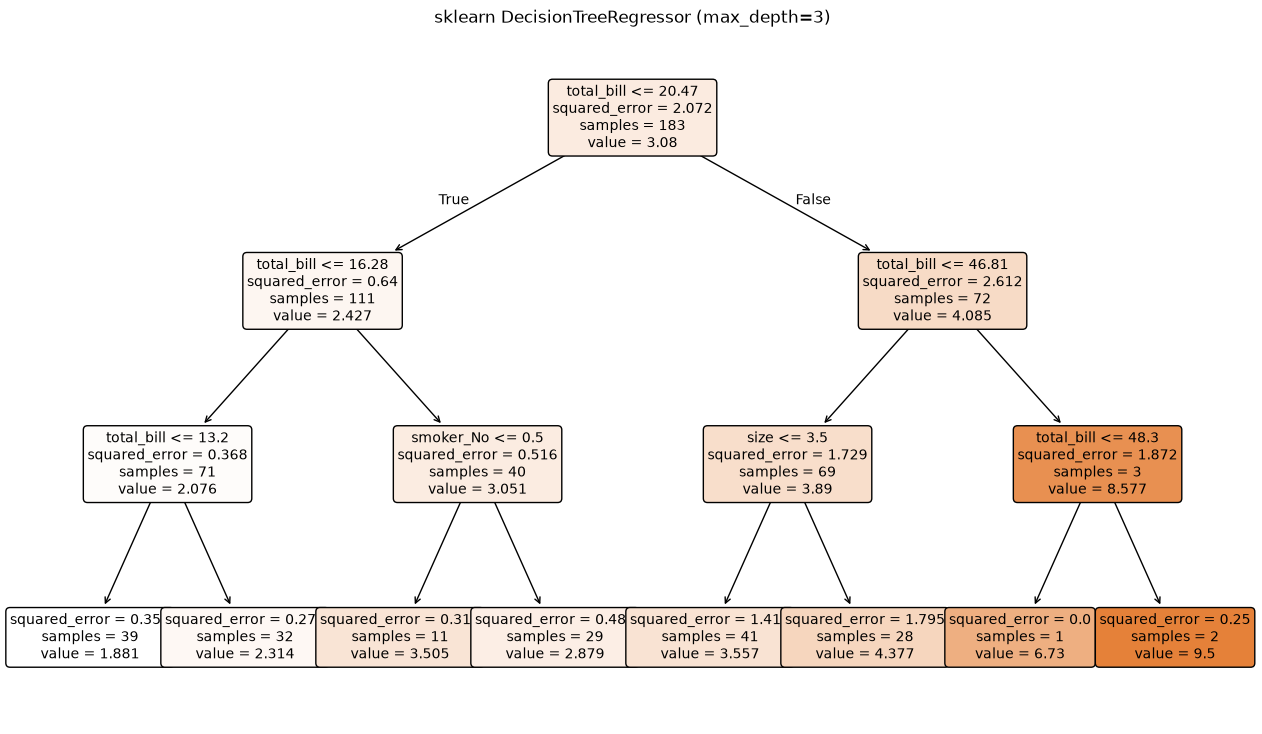

In [5]:
mine_d3 = MyDecisionTreeRegressor(max_depth=3, random_state=42).fit(X_tr, y_tr)
sk_d3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_tr, y_tr)

def print_tree(node, indent=0):
    prefix = '  ' * indent
    if node['leaf']:
        print(f'{prefix}Leaf: mean={node["mean"]:.4f}, n={node["n_samples"]}')
    else:
        print(f'{prefix}Node: X[{node["feature"]}] <= {node["threshold"]:.3f}, n={node["n_samples"]}')
        print_tree(node['left'], indent + 1)
        print_tree(node['right'], indent + 1)

print('=== Our tree (max_depth=3) ===')
print_tree(mine_d3.tree_)

plt.figure(figsize=(16, 9))
plot_tree(sk_d3, feature_names=feature_names, filled=True, rounded=True, fontsize=10)
plt.title('sklearn DecisionTreeRegressor (max_depth=3)')
plt.show()

### 5. Step-function visualization (1D)

Show the piecewise-constant nature of the tree predictions.

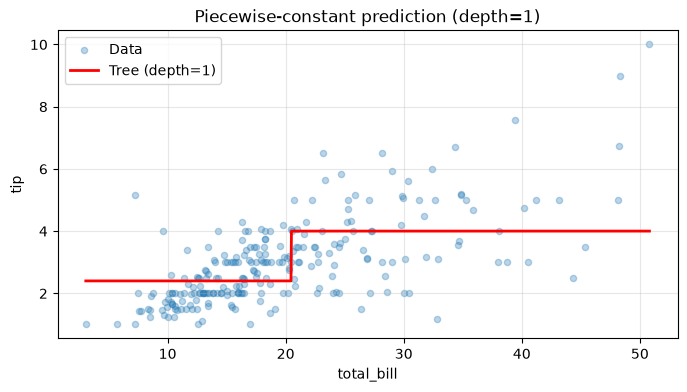

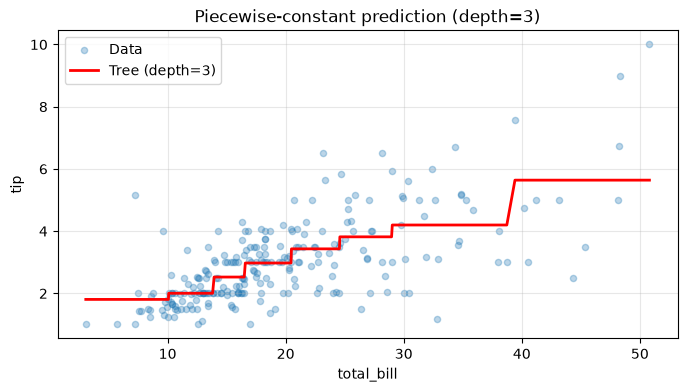

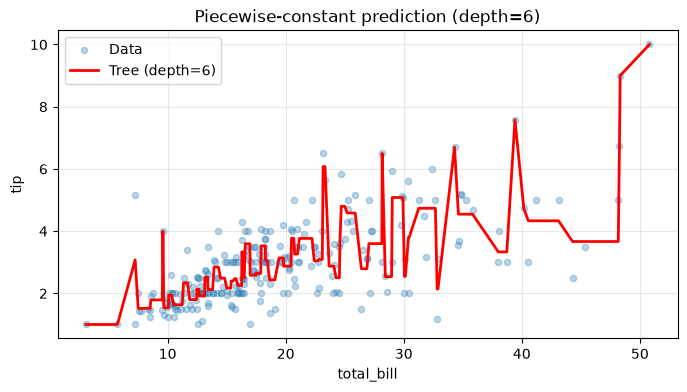

In [6]:
# 1D demo on total_bill vs tip
X_1d = tips[['total_bill']].values
y_1d = tips['tip'].values

# Sort for clean line plot
sort_idx = np.argsort(X_1d[:, 0])
X_sorted = X_1d[sort_idx, 0]
y_sorted = y_1d[sort_idx]

for depth in [1, 3, 6]:
    m = MyDecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_1d, y_1d)
    pred = m.predict(X_1d)
    pred_sorted = pred[sort_idx]
    plt.figure(figsize=(8, 4))
    plt.scatter(X_sorted, y_sorted, alpha=0.3, s=20, label='Data')
    plt.plot(X_sorted, pred_sorted, 'r-', linewidth=2, label=f'Tree (depth={depth})')
    plt.xlabel('total_bill')
    plt.ylabel('tip')
    plt.title(f'Piecewise-constant prediction (depth={depth})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 6. Feature importance comparison

In [7]:
sk_imp = pd.Series(sk_d3.feature_importances_, index=feature_names).sort_values(ascending=False)
print('Feature importances (sklearn, max_depth=3):')
print(sk_imp.round(4))

print(f'\nOur tree - depth: {print_tree(mine_d3.tree_) if False else "(shown above)"}')

def count_leaves(node):
    if node['leaf']:
        return 1
    return count_leaves(node['left']) + count_leaves(node['right'])

print(f'Our tree leaves: {count_leaves(mine_d3.tree_)}')
print(f'sklearn tree leaves: {sk_d3.get_n_leaves()}')

Feature importances (sklearn, max_depth=3):
total_bill     0.9379
size           0.0485
smoker_No      0.0136
sex_Female     0.0000
day_Fri        0.0000
day_Sat        0.0000
day_Sun        0.0000
time_Dinner    0.0000
dtype: float64

Our tree - depth: (shown above)
Our tree leaves: 8
sklearn tree leaves: 8


### Summary & key takeaways

- Regression trees are **piecewise-constant step functions**: each leaf predicts the region's mean.
- Split quality = **variance reduction** (SSE): pick feature + threshold maximizing $\Delta = SSE_{par} - (n_L SE_L + n_R SE_R)/n$.
- **Unconstrained trees overfit wildly** - train R² ~1.0, test R² much lower. Pruning essential.
- Key pruning: `max_depth`, `min_samples_split`, `min_samples_leaf`.
- Trees cannot extrapolate beyond training target range (predict constant steps).
- Feature importance = total variance reduction weighted by samples.
- Our implementation matches sklearn's structure/behavior on real data.